In [4]:
library(ggplot2)
library(ggrepel)
library(readxl)
library(dplyr)

Warning message:
“package ‘ggrepel’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
kurva_pertumbuhan <- function(
    df,
    who_source,
    local_source,
    ylab,
    ylim = NULL,
    xlab = "umur (Tahun)",
    xbreaks = NULL,
    ybreaks = NULL,
    show_legend = FALSE,
    sex_label = NULL
) {

    # --- prepare data ---
    plot_df <- df %>%
        mutate(
            Model = case_when(
                Source == who_source   ~ "Model Referensi WHO",
                Source == local_source ~ "Model Lokal",
                TRUE ~ NA_character_
            )
        ) %>%
        filter(!is.na(Model))

    plot_df$Z <- factor(plot_df$Z, levels = c("Z-2", "Z-1", "Z0", "Z1", "Z2"))

    if (is.null(ylim))  ylim <- range(plot_df$Value, na.rm = TRUE)

    if (is.null(xbreaks)) {
        xbreaks <- seq(
            floor(min(plot_df$umur, na.rm = TRUE)),
            ceiling(max(plot_df$umur, na.rm = TRUE)),
            by = 1
        )
    }

    if (is.null(ybreaks)) ybreaks <- pretty(ylim)

    # --- BUILD PLOT ---
    p <- ggplot(
        plot_df,
        aes(
            x = umur,
            y = Value,
            group = interaction(Z, Model),
            color = Z,
            linetype = Model
        )
    ) +
        geom_line(linewidth = 0.7, color = "white", lineend = "round") +
        geom_line(linewidth = 0.6, lineend = "round") +
        scale_x_continuous(breaks = xbreaks, expand = expansion(0)) +
        scale_y_continuous(
            limits = ylim, breaks = ybreaks, 
            expand = expansion(mult=c(0, 0.08))) +
        scale_color_manual(
            values = c(
                "Z-2" = "#0072B2",
                "Z-1" = "#56B4E9",
                "Z0"  = "#999999",
                "Z1"  = "#E69F00",
                "Z2"  = "#D55E00"
            ),
            drop = FALSE,
            name = NULL
        ) +
        scale_linetype_manual(
            values = c(
                "Model Referensi WHO" = "dashed",
                "Model Lokal"   = "solid"
            ),
            name = NULL
        ) +
        labs(x = xlab, y = ylab) +
        coord_cartesian(clip = "off") +
        theme_minimal(base_size = 12) +
        theme(
            axis.title.y = element_text(margin=margin(r=6)),
            legend.box = "horizontal",
            legend.position = if (show_legend) c(0.98, 0.02) else "none",
            legend.justification = c("right", "bottom"),
            legend.background = element_blank(),
            legend.box.background = element_blank(),
            legend.key.width = unit(0.5, "cm"),
            legend.key.height = unit(0.4, "cm"),
            legend.text = element_text(size = 10),

            panel.grid = element_blank(),
            axis.line = element_line(color = "black", linewidth = 0.5),
            axis.ticks = element_line(color = "black", linewidth = 0.5),
            axis.ticks.length = unit(0.15, "cm"),
            axis.text = element_text(size = 10, color = "black"),
            plot.margin = margin(t = 20, r = 4, b = 4, l = 24)
        )

    if (!is.null(sex_label)) {
    p <- p +
        annotation_custom(
            grid::textGrob(
                sex_label,
                x = unit(-0.05, "npc"),  
                y = unit(1.015, "npc"),      
                just = c("left", "bottom"),
                gp = grid::gpar(
                    fontsize = 12,
                    fontface = "plain"
                )
            )
        )
    }
}

## TINGGI BADAN LAKI2

In [5]:
male_tb <- read_excel("/home/okta/Documents/data-analysis/doni/zscores/male_tb_gabungan1219.xlsx")
male_tb

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.5,Z-2,121.8560,local_male_tb
11.5,Z-1,132.9785,local_male_tb
11.5,Z0,143.2075,local_male_tb
11.5,Z1,152.3215,local_male_tb
11.5,Z2,160.1767,local_male_tb
11.6,Z-2,122.6859,local_male_tb
11.6,Z-1,133.7387,local_male_tb
11.6,Z0,143.9083,local_male_tb
11.6,Z1,152.9716,local_male_tb


In [5]:
kurva_pertumbuhan <- function(
    df,
    who_source,
    local_source,
    ylab,
    ylim = NULL,
    xlab = "umur (Tahun)",
    xbreaks = NULL,
    ybreaks = NULL,
    show_legend = FALSE,
    sex_label = NULL
) {

    library(dplyr)
    library(ggplot2)

    # --- Prepare data ---
    plot_df <- df %>%
        mutate(
            Model = case_when(
                Source == who_source   ~ "Model Referensi WHO",
                Source == local_source ~ "Model Lokal",
                TRUE ~ NA_character_
            )
        ) %>%
        filter(!is.na(Model))

    plot_df$Z <- factor(plot_df$Z,
                        levels = c("Z-2", "Z-1", "Z0", "Z1", "Z2"),
                        labels = c("-2", "-1", "0", "+1", "+2"))

    if (is.null(ylim))
        ylim <- range(plot_df$Value, na.rm = TRUE)

    if (is.null(xbreaks)) {
        xbreaks <- seq(
            floor(min(plot_df$umur, na.rm = TRUE)),
            ceiling(max(plot_df$umur, na.rm = TRUE)),
            by = 1
        )
    }

    if (is.null(ybreaks))
        ybreaks <- pretty(ylim)

    # Data untuk label (hanya Model Lokal)
    label_df <- plot_df %>%
        filter(Model == "Model Lokal") %>%
        group_by(Z) %>%
        filter(umur == max(umur)) %>%
        ungroup()

    # --- Plot ---
    p <- ggplot(
        plot_df,
        aes(
            x = umur,
            y = Value,
            group = interaction(Z, Model),
            color = Z,
            linetype = Model
        )
    ) +
        geom_line(linewidth = 0.7, lineend = "round") +

        # Label di ujung kurva
        geom_text(
            data = label_df,
            aes(label = Z),
            hjust = -0.3,
            size = 3,
            show.legend = FALSE
        ) +

        scale_x_continuous(
            breaks = xbreaks,
            expand = expansion(mult = c(0, 0.05))
        ) +

        scale_y_continuous(
            limits = ylim,
            breaks = ybreaks,
            expand = expansion(mult = c(0, 0.08))
        ) +

        scale_color_manual(
            values = c(
                "-2" = "#0072B2",
                "-1" = "#56B4E9",
                "0"  = "#999999",
                "+1" = "#E69F00",
                "+2" = "#D55E00"
            ),
            guide = "none"
        ) +

        scale_linetype_manual(
            values = c(
                "Model Referensi WHO" = "33",
                "Model Lokal"   = "solid"
            ),
            name = NULL
        ) +

        labs(x = xlab, y = ylab) +

        coord_cartesian(clip = "off") +

        theme_minimal(base_size = 12) +
        theme(
            panel.grid = element_blank(),
            axis.line = element_line(color = "black", linewidth = 0.5),
            axis.ticks = element_line(color = "black", linewidth = 0.5),
            axis.text = element_text(size = 10, color = "black"),
            plot.margin = margin(t = 20, r = 30, b = 4, l = 24),
            legend.position = if (show_legend) c(0.98, 0.02) else "none",
            legend.justification = c("right", "bottom")
        )

    if (!is.null(sex_label)) {
        p <- p +
            ggtitle(sex_label) +
            theme(
                plot.title = element_text(
                    size = 12,
                    hjust = 0,
                    face = "plain"
                )
            )
    }

    return(p)
}


In [3]:
kurva_pertumbuhan <- function(
    df,
    who_source,
    local_source,
    ylab,
    ylim = NULL,
    xlab = "umur (Tahun)",
    max_umur = NULL,       # <--- TAMBAHAN 1: Parameter baru dengan default NULL
    xbreaks = NULL,
    ybreaks = NULL,
    show_legend = FALSE,
    sex_label = NULL
) {

    # --- prepare data ---
    plot_df <- df %>%
        mutate(
            Model = case_when(
                Source == who_source   ~ "Model Referensi WHO",
                Source == local_source ~ "Model Lokal",
                TRUE ~ NA_character_
            )
        ) %>%
        filter(!is.na(Model))
    
    # <--- TAMBAHAN 2: Logika subsetting untuk batas usia maksimal
    if (!is.null(max_umur)) {
        plot_df <- plot_df %>%
            filter(umur <= max_umur)
    }

    plot_df$Z <- factor(plot_df$Z, levels = c("Z-2", "Z-1", "Z0", "Z1", "Z2"))

    if (is.null(ylim))  ylim <- range(plot_df$Value, na.rm = TRUE)

    if (is.null(xbreaks)) {
        xbreaks <- seq(
            floor(min(plot_df$umur, na.rm = TRUE)),
            ceiling(max(plot_df$umur, na.rm = TRUE)),
            by = 1
        )
    }

    if (is.null(ybreaks)) ybreaks <- pretty(ylim)

    # --- BUILD PLOT ---
    p <- ggplot(
        plot_df,
        aes(
            x = umur,
            y = Value,
            group = interaction(Z, Model),
            color = Z,
            linetype = Model
        )
    ) +
        geom_line(linewidth = 0.7, color = "white", lineend = "round") +
        geom_line(linewidth = 0.6, lineend = "round") +
        scale_x_continuous(
            breaks = xbreaks, 
            limits = c(min(xbreaks), max(xbreaks) + 0.5), 
            expand = expansion(mult = c(0, 0.02))
            )+
        scale_y_continuous(
            limits = ylim, breaks = ybreaks, 
            expand = expansion(mult=c(0, 0.08))) +
        scale_color_manual(
            values = c(
                "Z-2" = "#0072B2",
                "Z-1" = "#56B4E9",
                "Z0"  = "#999999",
                "Z1"  = "#E69F00",
                "Z2"  = "#D55E00"
            ),
            drop = FALSE,
            name = NULL
        ) +
        scale_linetype_manual(
            values = c(
                "Model Referensi WHO" = "dashed",
                "Model Lokal"   = "solid"
            ),
            name = NULL
        ) +
        labs(x = xlab, y = ylab) +
        coord_cartesian(clip = "off") +
        theme_minimal(base_size = 12) +
        theme(
            axis.title.y = element_text(margin=margin(r=6)),
            legend.box = "horizontal",
            legend.position = if (show_legend) c(0.98, 0.02) else "none",
            legend.justification = c("right", "bottom"),
            legend.background = element_blank(),
            legend.box.background = element_blank(),
            legend.key.width = unit(0.5, "cm"),
            legend.key.height = unit(0.4, "cm"),
            legend.text = element_text(size = 10),

            panel.grid = element_blank(),
            axis.line = element_line(color = "black", linewidth = 0.5),
            axis.ticks = element_line(color = "black", linewidth = 0.5),
            axis.ticks.length = unit(0.15, "cm"),
            axis.text = element_text(size = 10, color = "black"),
            plot.margin = margin(t = 20, r = 4, b = 4, l = 24)
        )

    if (!is.null(sex_label)) {
    p <- p +
        annotation_custom(
            grid::textGrob(
                sex_label,
                x = unit(-0.05, "npc"),  
                y = unit(1.015, "npc"),      
                just = c("left", "bottom"),
                gp = grid::gpar(
                    fontsize = 12,
                    fontface = "plain"
                )
            )
        )
    }
    
    return(p) # Praktik yang baik: pastikan selalu mengembalikan objek plot di akhir fungsi
}

In [6]:
# zscore diujung garis
kurva_pertumbuhan2 <- function(
    df,
    who_source,
    local_source,
    ylab,
    ylim = NULL,
    xlab = "umur (Tahun)",
    max_umur = NULL,
    xbreaks = NULL,
    ybreaks = NULL,
    show_legend = FALSE,
    sex_label = NULL
) {

    # --- 1. Prepare Main Data ---
    plot_df <- df %>%
        mutate(
            Model = case_when(
                Source == who_source   ~ "Model Referensi WHO",
                Source == local_source ~ "Model Lokal",
                TRUE ~ NA_character_
            )
        ) %>%
        filter(!is.na(Model))
    
    if (!is.null(max_umur)) {
        plot_df <- plot_df %>%
            filter(umur <= max_umur)
    }

    plot_df$Z <- factor(plot_df$Z, levels = c("Z-2", "Z-1", "Z0", "Z1", "Z2"))

    # --- 2. Prepare Label Data (Titik Ujung) ---
    # Kita hanya mengambil titik terakhir dari 'Model Lokal' untuk label
    label_df <- plot_df %>%
        filter(Model == "Model Lokal") %>%
        group_by(Z) %>%
        filter(umur == max(umur, na.rm = TRUE)) %>%
        ungroup()

    if (is.null(ylim))  ylim <- range(plot_df$Value, na.rm = TRUE)

    if (is.null(xbreaks)) {
        xbreaks <- seq(
            floor(min(plot_df$umur, na.rm = TRUE)),
            ceiling(max(plot_df$umur, na.rm = TRUE)),
            by = 1
        )
    }

    if (is.null(ybreaks)) ybreaks <- pretty(ylim)

    # --- 3. Build Plot ---
    p <- ggplot(
        plot_df,
        aes(
            x = umur,
            y = Value,
            group = interaction(Z, Model),
            color = Z,
            linetype = Model
        )
    ) +
        # Layer garis
        geom_line(linewidth = 0.7, color = "white", lineend = "round") +
        geom_line(linewidth = 0.6, lineend = "round") +
        
        # Layer Label di Ujung (Direct Labeling)
        geom_text(
            data = label_df,
            aes(label = Z),
            hjust = -0.3,          # Menggeser teks ke kanan agar tidak menumpuk di garis
            size = 3.5,
            fontface = "bold",
            show.legend = FALSE    # Agar huruf 'a' tidak muncul di legend kotak
        ) +
        
        scale_x_continuous(
            breaks = xbreaks, 
            # Memberikan ruang 0.8 tahun di kanan untuk tempat teks
            limits = c(min(xbreaks), max(xbreaks) + 0.8), 
            expand = expansion(mult = c(0, 0.02))
        ) +
        scale_y_continuous(
            limits = ylim, breaks = ybreaks, 
            expand = expansion(mult=c(0, 0.08))) +
        scale_color_manual(
            values = c(
                "Z-2" = "#0072B2", "Z-1" = "#56B4E9", "Z0"  = "#999999",
                "Z1"  = "#E69F00", "Z2"  = "#D55E00"
            ),
            drop = FALSE,
            name = NULL
        ) +
        scale_linetype_manual(
            values = c("Model Referensi WHO" = "dashed", "Model Lokal" = "solid"),
            name = NULL
        ) +
        labs(x = xlab, y = ylab) +
        coord_cartesian(clip = "off") + # Penting: agar teks di luar panel tidak terpotong
        theme_minimal(base_size = 12) +
        theme(
            axis.title.y = element_text(margin=margin(r=6)),
            legend.box = "horizontal",
            legend.position = if (show_legend) "bottom" else "none",
            legend.justification = "center",
            panel.grid = element_blank(),
            axis.line = element_line(color = "black", linewidth = 0.5),
            axis.ticks = element_line(color = "black", linewidth = 0.5),
            axis.ticks.length = unit(0.15, "cm"),
            axis.text = element_text(size = 10, color = "black"),
            plot.margin = margin(t = 20, r = 35, b = 4, l = 24) # Margin kanan diperlebar
        )

    if (!is.null(sex_label)) {
        p <- p +
            annotation_custom(
                grid::textGrob(
                    sex_label, x = unit(-0.05, "npc"), y = unit(1.015, "npc"),      
                    just = c("left", "bottom"),
                    gp = grid::gpar(fontsize = 12, fontface = "plain")
                )
            )
    }
    
    return(p)
}

In [11]:
kurva_pertumbuhan4 <- function(
    df,
    who_source,
    local_source,
    ylab,
    ylim = NULL,
    xlab = "umur (Tahun)",
    max_umur = NULL,
    xbreaks = NULL,
    ybreaks = NULL,
    show_legend = FALSE,
    sex_label = NULL
) {

    # --- 1. Prepare Main Data ---
    plot_df <- df %>%
        mutate(
            Model = case_when(
                Source == who_source   ~ "Model Referensi WHO",
                Source == local_source ~ "Model Lokal",
                TRUE ~ NA_character_
            )
        ) %>%
        filter(!is.na(Model))
    
    if (!is.null(max_umur)) {
        plot_df <- plot_df %>%
            filter(umur <= max_umur)
    }

    plot_df$Z <- factor(plot_df$Z, levels = c("Z-2", "Z-1", "Z0", "Z1", "Z2"))

    # --- 2. Prepare Label Data (Titik Ujung) ---
    label_df <- plot_df %>%
        filter(Model == "Model Lokal") %>%
        group_by(Z) %>%
        filter(umur == max(umur, na.rm = TRUE)) %>%
        ungroup()

    if (is.null(ylim))  ylim <- range(plot_df$Value, na.rm = TRUE)

    if (is.null(xbreaks)) {
        xbreaks <- seq(
            floor(min(plot_df$umur, na.rm = TRUE)),
            ceiling(max(plot_df$umur, na.rm = TRUE)),
            by = 1
        )
    }

    if (is.null(ybreaks)) ybreaks <- pretty(ylim)

    # --- 3. Build Plot ---
    p <- ggplot(
        plot_df,
        aes(
            x = umur,
            y = Value,
            group = interaction(Z, Model),
            color = Z,
            linetype = Model
        )
    ) +
        geom_line(linewidth = 0.7, color = "white", lineend = "round") +
        geom_line(linewidth = 0.6, lineend = "round") +
        
        geom_text(
            data = label_df,
            aes(label = Z),
            hjust = -0.3,
            size = 3.5,
            fontface = "bold",
            show.legend = FALSE
        ) +
        
        scale_x_continuous(
            breaks = xbreaks, 
            limits = c(min(xbreaks), max(xbreaks) + 0.8), 
            expand = expansion(mult = c(0, 0.02))
        ) +
        scale_y_continuous(
            limits = ylim, breaks = ybreaks, 
            expand = expansion(mult=c(0, 0.08))
        ) +
        scale_color_manual(
            values = c(
                "Z-2" = "#0072B2", "Z-1" = "#56B4E9", "Z0"  = "#999999",
                "Z1"  = "#E69F00", "Z2"  = "#D55E00"
            ),
            drop = FALSE,
            name = NULL,
            guide = "none" # <--- MENGHAPUS LEGEND WARNA (Z-SCORE)
        ) +
        scale_linetype_manual(
            values = c("Model Referensi WHO" = "dashed", "Model Lokal" = "solid"),
            name = NULL
        ) +
        labs(x = xlab, y = ylab) +
        coord_cartesian(clip = "off") +
        theme_minimal(base_size = 12) +
        theme(
            axis.title.y = element_text(margin=margin(r=6)),
            legend.box = "horizontal",
            # <--- MENGEMBALIKAN POSISI LEGEND KE DALAM PLOT
            legend.position = if (show_legend) c(0.98, 0.02) else "none", 
            legend.justification = c("right", "bottom"),
            legend.background = element_blank(),
            legend.box.background = element_blank(),
            legend.key.width = unit(0.5, "cm"),
            legend.key.height = unit(0.4, "cm"),
            legend.text = element_text(size = 10),

            panel.grid = element_blank(),
            axis.line = element_line(color = "black", linewidth = 0.5),
            axis.ticks = element_line(color = "black", linewidth = 0.5),
            axis.ticks.length = unit(0.15, "cm"),
            axis.text = element_text(size = 10, color = "black"),
            plot.margin = margin(t = 20, r = 35, b = 4, l = 24)
        )

    if (!is.null(sex_label)) {
        p <- p +
            annotation_custom(
                grid::textGrob(
                    sex_label, x = unit(-0.05, "npc"), y = unit(1.015, "npc"),      
                    just = c("left", "bottom"),
                    gp = grid::gpar(fontsize = 12, fontface = "plain")
                )
            )
    }
    
    return(p)
}

In [37]:
kurva_pertumbuhan5 <- function(
    df,
    who_source,
    local_source,
    ylab,
    ylim = NULL,
    xlab = "umur (Tahun)",
    max_umur = NULL,
    xbreaks = NULL,
    ybreaks = NULL,
    show_legend = FALSE,
    sex_label = NULL
) {

    # --- 1. Prepare Main Data ---
    plot_df <- df %>%
        mutate(
            Model = case_when(
                Source == who_source   ~ "Model Referensi WHO",
                Source == local_source ~ "Model Lokal",
                TRUE ~ NA_character_
            )
        ) %>%
        filter(!is.na(Model))
    
    if (!is.null(max_umur)) {
        plot_df <- plot_df %>%
            filter(umur <= max_umur)
    }

    plot_df$Z <- factor(plot_df$Z, levels = c("Z-2", "Z-1", "Z0", "Z1", "Z2"))

    # --- 2. Prepare Label Data (Titik Ujung) ---
    label_df <- plot_df %>%
        filter(Model == "Model Lokal") %>%
        group_by(Z) %>%
        filter(umur == max(umur, na.rm = TRUE)) %>%
        ungroup()

    if (is.null(ylim))  ylim <- range(plot_df$Value, na.rm = TRUE)

    if (is.null(xbreaks)) {
        # 1. Ambil nilai asli minimal (misal 11.5)
        min_x_raw <- min(plot_df$umur, na.rm = TRUE)
        
        # 2. Tentukan batas atas (max_umur atau dari data)
        max_x <- if (!is.null(max_umur)) max_umur else ceiling(max(plot_df$umur, na.rm = TRUE))
        
        # 3. Buat urutan angka bulat mulai dari angka bulat setelah min_x_raw
        # Jika min_x_raw = 11.5, maka ceiling(min_x_raw) = 12
        integers <- seq(ceiling(min_x_raw), max_x, by = 1)
        
        # 4. Gabungkan nilai asli tadi dengan deret angka bulatnya
        # unique() digunakan untuk berjaga-jaga jika min_x_raw sudah angka bulat
        xbreaks <- unique(c(min_x_raw, integers))
    }

    if (is.null(ybreaks)) ybreaks <- pretty(ylim)

    # --- 3. Build Plot ---
    p <- ggplot(
        plot_df,
        aes(
            x = umur,
            y = Value,
            group = interaction(Z, Model),
            color = Z,
            linetype = Model
        )
    ) +
        geom_line(linewidth = 0.7, color = "white", lineend = "round") +
        geom_line(linewidth = 0.6, lineend = "round") +
        
        geom_text(
            data = label_df,
            aes(label = Z),
            hjust = -0.3,
            size = 3.5,
            fontface = "bold",
            show.legend = FALSE
        ) +
        
        scale_x_continuous(
            breaks = xbreaks, 
            limits = c(min(xbreaks), max(xbreaks) + 0.8), 
            expand = expansion(mult = c(0, 0.02))
        ) +
        scale_y_continuous(
            limits = ylim, breaks = ybreaks, 
            expand = expansion(mult=c(0, 0.08))
        ) +
        scale_color_manual(
            values = c(
                "Z-2" = "#0072B2", "Z-1" = "#56B4E9", "Z0"  = "#999999",
                "Z1"  = "#E69F00", "Z2"  = "#D55E00"
            ),
            drop = FALSE,
            name = NULL,
            guide = "none" 
        ) +
        scale_linetype_manual(
            values = c(
                "Model Referensi WHO" = "22", # Menggunakan custom dash pattern yang lebih rapat
                "Model Lokal" = "solid"
            ),
            name = NULL
        ) +
        labs(x = xlab, y = ylab) +
        coord_cartesian(clip = "off") +
        theme_minimal(base_size = 12) +
        theme(
            axis.title.y = element_text(margin=margin(r=6)),
            legend.box = "horizontal",
            legend.position = if (show_legend) c(0.98, 0.02) else "none", 
            legend.justification = c("right", "bottom"),
            legend.background = element_blank(),
            legend.box.background = element_blank(),
            legend.key.width = unit(1.2, "cm"), # Jendela legend diperlebar agar garis putus-putus terlihat
            legend.key.height = unit(0.4, "cm"),
            legend.text = element_text(size = 10),

            panel.grid = element_blank(),
            axis.line = element_line(color = "black", linewidth = 0.5),
            axis.ticks = element_line(color = "black", linewidth = 0.5),
            axis.ticks.length = unit(0.15, "cm"),
            axis.text = element_text(size = 10, color = "black"),
            plot.margin = margin(t = 20, r = 35, b = 4, l = 24)
        )

    if (!is.null(sex_label)) {
        p <- p +
            annotation_custom(
                grid::textGrob(
                    sex_label, x = unit(-0.05, "npc"), y = unit(1.015, "npc"),      
                    just = c("left", "bottom"),
                    gp = grid::gpar(fontsize = 12, fontface = "plain")
                )
            )
    }
    
    return(p)
}

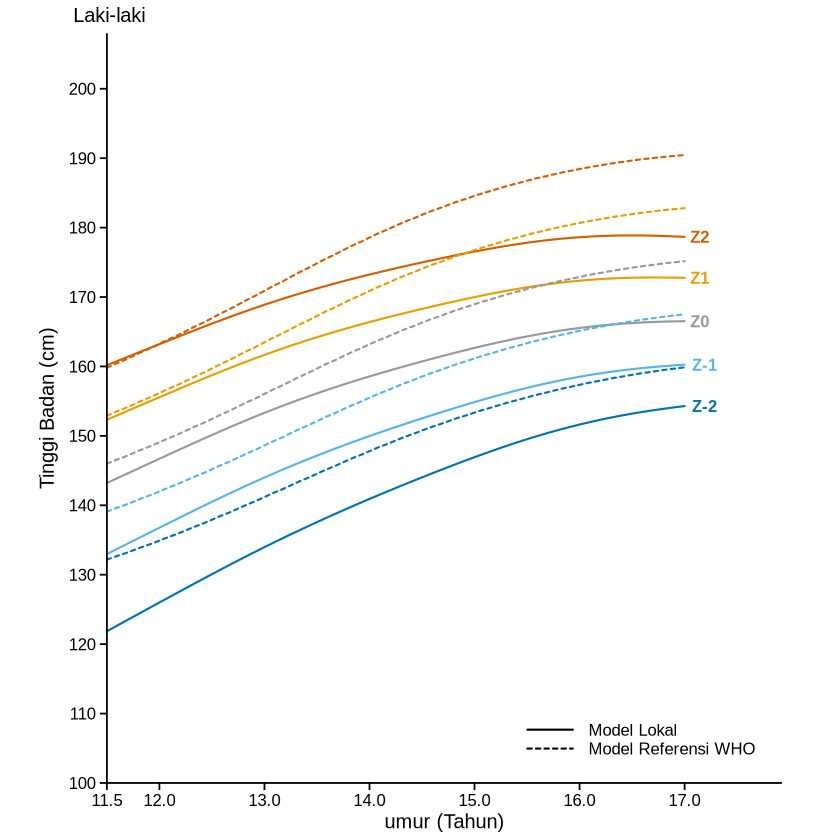

In [38]:
kurva_tb_male <- kurva_pertumbuhan5(
    df = male_tb,
    who_source = "WHO_tb_male",
    local_source = "local_male_tb",
    ylab = "Tinggi Badan (cm)",
    ylim = c(100, 200),
    max_umur = 17,                 # <--- Set batas umur di sini
    xbreaks = NULL, # seq(11.5, 17, 1),      # <--- Pastikan batas atas sequence disesuaikan dengan max_umur
    ybreaks = seq(100, 200, 10),
    show_legend = TRUE,
    sex_label = "Laki-laki"
)

kurva_tb_male

In [39]:
ggsave("tb_male.png", kurva_tb_male, 
       width = 8, height = 8, dpi = 1200,
       bg="white")  # 2:1 ratio

## BMI

In [25]:
male_bmi <- read_excel("/home/okta/Documents/data-analysis/doni/zscores/male_bmi_gabungan1219.xlsx")

In [26]:
male_bmi

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.5,Z-2,13.60474,local_male_bmi.xlsx
11.5,Z-1,15.34024,local_male_bmi.xlsx
11.5,Z0,18.27336,local_male_bmi.xlsx
11.5,Z1,22.81857,local_male_bmi.xlsx
11.5,Z2,29.02282,local_male_bmi.xlsx
11.6,Z-2,13.62812,local_male_bmi.xlsx
11.6,Z-1,15.36303,local_male_bmi.xlsx
11.6,Z0,18.29802,local_male_bmi.xlsx
11.6,Z1,22.85525,local_male_bmi.xlsx


In [27]:
male_bmi$Source[male_bmi$Source == "local_male_bmi.xlsx"] <- "local_bmi_male"
male_bmi$Source[male_bmi$Source == "WHO_tb_male"] <- "who_bmi_male"
male_bmi

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.5,Z-2,13.60474,local_bmi_male
11.5,Z-1,15.34024,local_bmi_male
11.5,Z0,18.27336,local_bmi_male
11.5,Z1,22.81857,local_bmi_male
11.5,Z2,29.02282,local_bmi_male
11.6,Z-2,13.62812,local_bmi_male
11.6,Z-1,15.36303,local_bmi_male
11.6,Z0,18.29802,local_bmi_male
11.6,Z1,22.85525,local_bmi_male


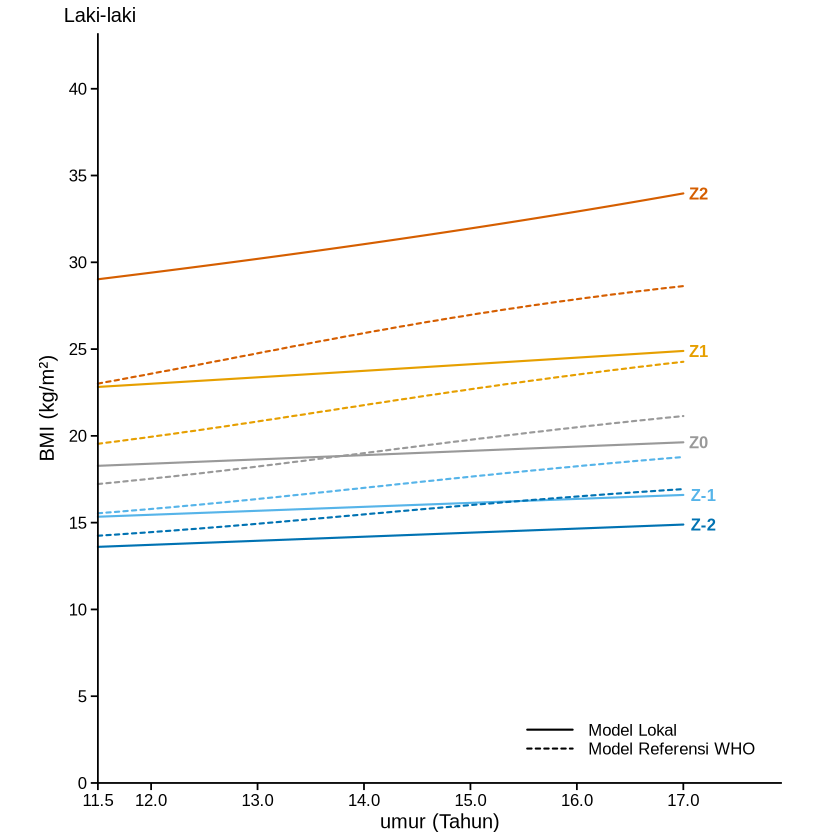

In [40]:
kurva_bmi_male <- kurva_pertumbuhan5(
    df = male_bmi,
    who_source = "who_bmi_male",
    local_source = "local_bmi_male",
    ylab = "BMI (kg/m²)",
    ylim = c(0, 40),
    max_umur = 17,
    xbreaks = NULL, # seq(11.5, 17, 1),
    ybreaks = seq(0, 40, 5),
    show_legend = TRUE,
    sex_label = "Laki-laki"
)
kurva_bmi_male

In [42]:
ggsave("bmi_male.png", kurva_bmi_male, 
       width = 8, height = 8, dpi = 1200,
       bg="white")  # 2:1 ratio

## FEMALE TB

In [29]:
female_tb <- read_excel("/home/okta/Documents/data-analysis/doni/plotting/zscore_tb_female.xlsx")
female_tb

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.5,Z-2,134.8010,local_tb_female
11.5,Z-1,141.5846,local_tb_female
11.5,Z0,147.1799,local_tb_female
11.5,Z1,152.3754,local_tb_female
11.5,Z2,157.7507,local_tb_female
11.6,Z-2,135.0084,local_tb_female
11.6,Z-1,141.7813,local_tb_female
11.6,Z0,147.3793,local_tb_female
11.6,Z1,152.5857,local_tb_female


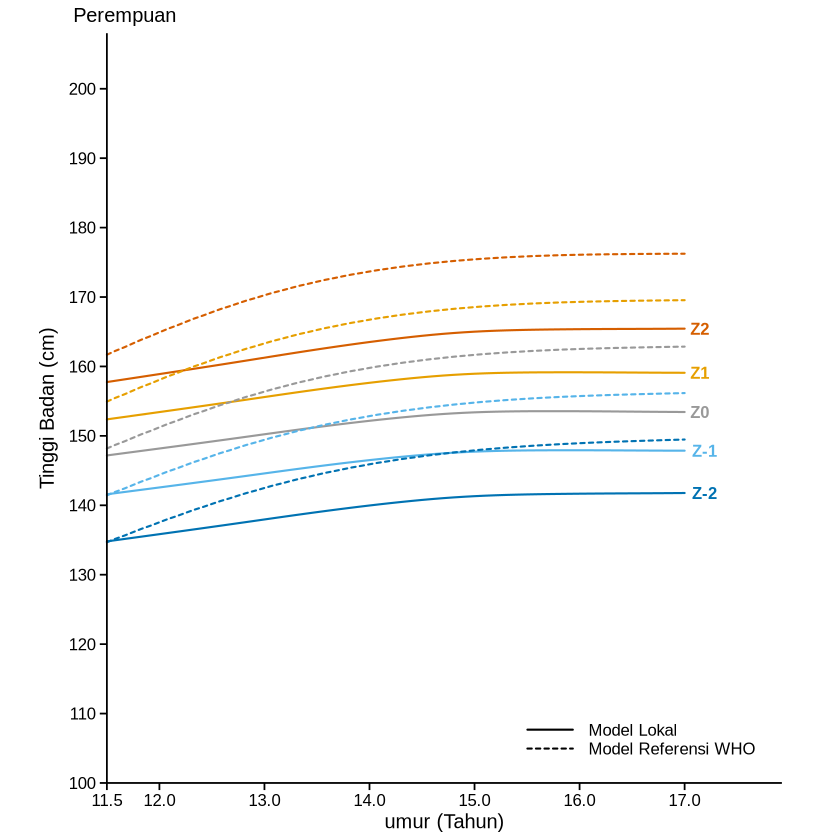

In [41]:
kurva_tb_female <- kurva_pertumbuhan5(
    df = female_tb,
    who_source = "WHO_tb_female",
    local_source = "local_tb_female",
    ylab = "Tinggi Badan (cm)",
    ylim = c(100, 200),
    max_umur = 17,
    xbreaks = NULL, # seq(11.5, 17, 1),
    ybreaks = seq(100, 200, 10),
    show_legend = TRUE,
    sex_label = "Perempuan"
)
kurva_tb_female

In [43]:
ggsave("tb_female.png", kurva_tb_female, 
       width = 8, height = 8, dpi = 1200,
       bg="white")  # 2:1 ratio

In [44]:
female_bmi <- read_excel("/home/okta/Documents/data-analysis/doni/plotting/zscore_bmi_female.xlsx")
female_bmi

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.5,Z-2,13.90811,local_bmi_female
11.5,Z-1,15.86691,local_bmi_female
11.5,Z0,18.60146,local_bmi_female
11.5,Z1,22.73174,local_bmi_female
11.5,Z2,29.82743,local_bmi_female
11.6,Z-2,13.93054,local_bmi_female
11.6,Z-1,15.89250,local_bmi_female
11.6,Z0,18.63147,local_bmi_female
11.6,Z1,22.76841,local_bmi_female


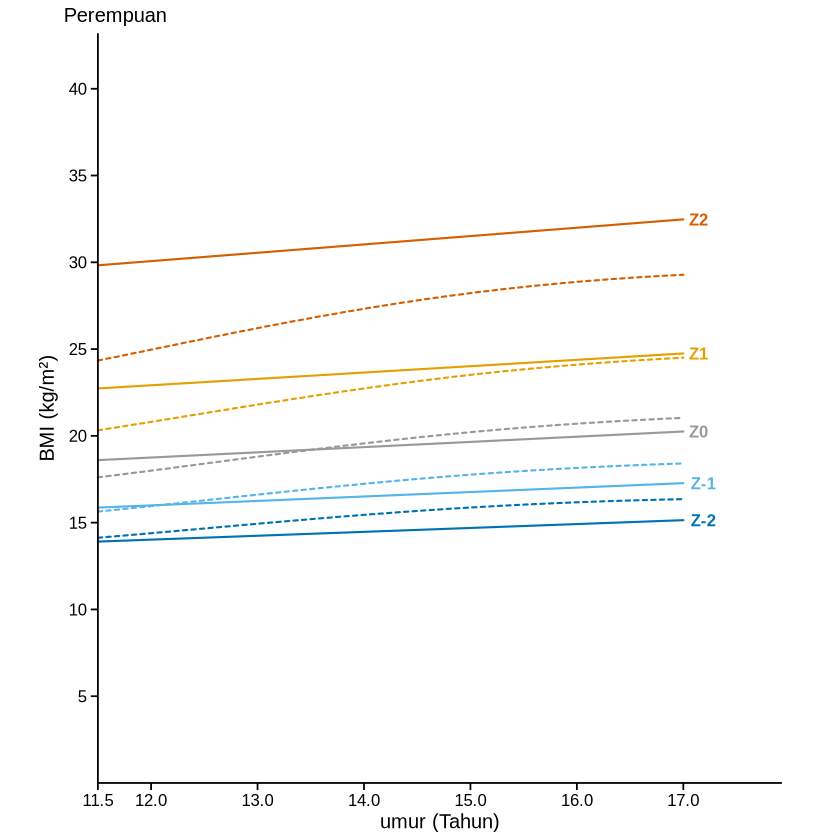

In [45]:
kurva_bmi_female <- kurva_pertumbuhan5(
    df = female_bmi,
    who_source = "WHO_bmi_female",
    local_source = "local_bmi_female",
    ylab = "BMI (kg/m²)",
    ylim = c(0, 40),
    max_umur = 17,
    xbreaks = NULL, #seq(11, 17, 1),
    ybreaks = seq(5, 40, 5),
    show_legend = FALSE,
    sex_label = "Perempuan"
)
kurva_bmi_female

In [49]:
ggsave("bmi_female.png", kurva_bmi_female, 
       width = 8, height = 8, dpi = 1200,
       bg="white")  # 2:1 ratio


In [50]:
theme_no_y <- theme(
    axis.title.y = element_blank(),
    axis.text.y  = element_blank()
)

theme_no_x <- theme(
    axis.title.x = element_blank(),
    axis.text.x  = element_blank()
)

In [51]:
library(patchwork)

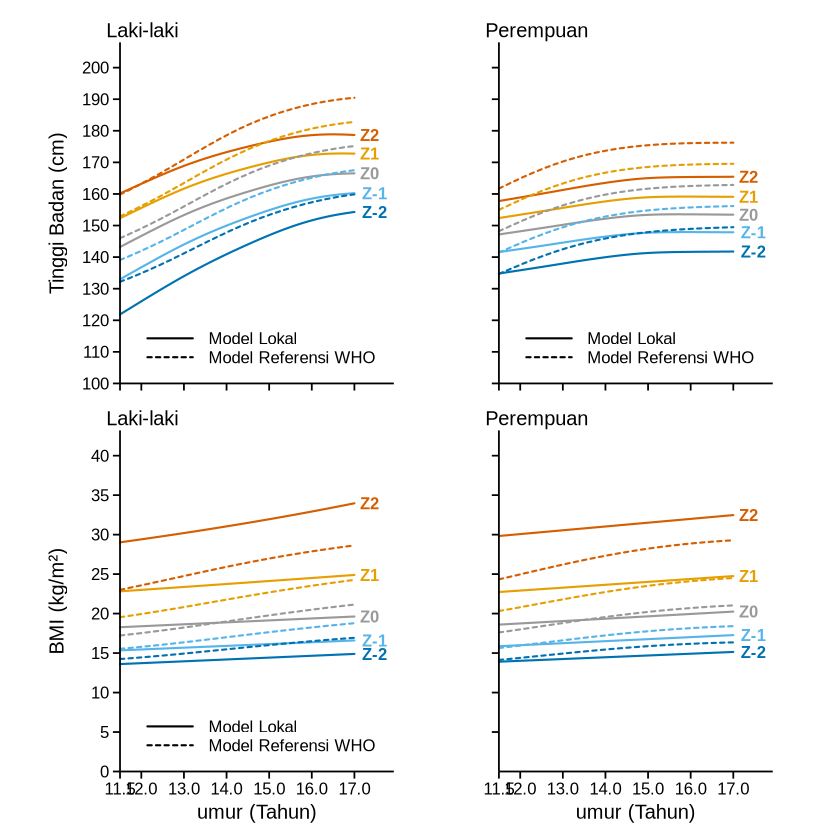

In [52]:
final_plot <-
    (kurva_tb_male + theme_no_x | kurva_tb_female + theme_no_y + theme_no_x)/
    (kurva_bmi_male | kurva_bmi_female + theme_no_y)
    

final_plot

In [80]:
ggsave("plot.pdf", final_plot, 
       width = 12, height = 8, dpi = 1200,
       bg="white")  # 2:1 ratio

In [ ]:
ggsave("plot.png", final_plot, 
       width = 12, height = 8, dpi = 1200,
       bg="white")  # 2:1 rati